In [3]:
%autoreload 2

In [48]:
%reload_ext autoreload
import os, sys, random
import numpy as np
import pandas as pd
import seaborn as sns

from scipy.stats import zscore
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib import gridspec, rcParams
from datetime import datetime as dt, timedelta
import pingouin as pg
import scipy.stats as stats
from fish import Gafftopsail
sys.path.append(r'/Users/zichenhe/miniforge3/envs/naumann_lab/2ptank/')#(r'C://Users//Zichen//anaconda3//envs//2ptank//Lib//site-packages//')
import utils
path = ('/Users/zichenhe/Desktop/fishes/Imaging/251224_overlap/fish2_HB/')
rcParams['font.size'] = 4  

In [49]:
fish = Gafftopsail(path, filelist = ['stimulus', 'imaging'], sequence = 5)
fish.stimulus_df.stim_name = [str(s) for s in fish.stimulus_df.stim_name]

__EACH STIM__

In [50]:
def get_pertrial_f(fish):
    """
    Get the dF/F for the fish organized by stimulus and trials, the f includes the entire duration of the stimulus (stationary + moving period)
    :param fish: 
    :param stim_onset_type: if 'overlap', the stationary time for overlap stim counts the time before the overlap starts; if 'gratings', the stationary time for overlap stim counts when the grating starts
    :return: 
    """
    stim_list = fish.stimulus_df.stim_name.unique()
    f_pertrial_dict = {stim: None for stim in stim_list}
    for stim in stim_list:
        #get important stimulus information
        stim_df = fish.stimulus_df[fish.stimulus_df['stim_name'] == stim].reset_index(drop=True)
        duration = stim_df['duration'].iloc[0] + 20
        #define plotting range (what are the frames of data to grab in general)
        image_range_frame = (0, int((duration) / fish.image_s))#general
        #for this stimulus, get the data shaped like trial, neuron, time
        #axis 0: trial; axis 1: neuron; axis 2: frame
        f_pertrial_perplane = {plane: np.full(shape=(len(stim_df), len(fish.f_dict[plane]), image_range_frame[1] - image_range_frame[0]), fill_value=np.nan) for plane in fish.planes}
        for trial, stim_row in stim_df.iterrows():
            for plane in fish.planes:
                start_frame = utils.find_nearest_frameindex(fish.frametimes_dict[plane], stim_row['real_starttime_s'])#this is frmae at stim start time
                try:
                    f_pertrial_perplane[plane][trial, :, :] = fish.f_dict[plane].iloc[:, start_frame + image_range_frame[0]:start_frame + image_range_frame[1]]
                except ValueError:
                    print('imaging ends before last visstim')
                    temp_f = fish.f_dict[plane].iloc[:,start_frame + image_range_frame[0]:start_frame + image_range_frame[1]]
                    f_pertrial_perplane[plane][trial, :, :temp_f.shape[1]] = temp_f
        f_pertrial_dict[stim] = np.concatenate([f for f in f_pertrial_perplane.values()], axis = 1)#OG index still gets maintained
    return f_pertrial_dict

In [51]:
#axis 0: trial; axis 1: neuron; axis 2: frame
#from stationary start to duration + 20
f_pertrial_dict = get_pertrial_f(fish)

In [86]:
stim_list = ['dot_l', 'dot_r', 'forward', str(['dot_l', 'forward']), str(['dot_r', 'forward']),
            'left', str(['dot_l', 'left']), str(['dot_r', 'left']),
             'right', str(['dot_l', 'right']), str(['dot_r', 'right']),
             'backward', str(['dot_l', 'backward']), str(['dot_r', 'backward'])]

stim_dict = {'dot_l': 'darkgray', 'dot_r': 'black', 
             'forward': 'darkgreen', str(['dot_l', 'forward']): 'lightgreen', str(['dot_r', 'forward']): 'limegreen',
            'left': 'mediumblue', str(['dot_l', 'left']):'lightsteelblue', str(['dot_r', 'left']):'royalblue',
             'right': 'maroon', str(['dot_l', 'right']): 'lightcoral', str(['dot_r', 'right']): 'indianred',
             'backward': 'indigo', str(['dot_l', 'backward']): 'plum', str(['dot_r', 'backward']):'mediumpurple' }

In [53]:
def get_response_index_f(fish, f_pertrial_dict, stim_list, baseline_s =10, response_s = 10):
    f_response_dict = {}
    for stim in stim_list:
        stim_df = fish.stimulus_df[fish.stimulus_df['stim_name'] == stim].reset_index(drop=True)
        stationary_time = stim_df['stationary_time'].iloc[0]
        if '[' in stim:#overlap
            stationary_time = min(stationary_time)
        #define plotting range (what are the frames of data to grab in general)
        
        stationary_frame = int(stationary_time/fish.image_s)
        baseline_frame = int((stationary_time - baseline_s)/ fish.image_s)#how many frame before stationary frame
        response_frame = int((stationary_time + response_s)/ fish.image_s)#how many frame after stationary frame
        #get all the baseline per trial
        f_pertrial = f_pertrial_dict[stim]
        f_pertrial_baseline = f_pertrial[:, :, baseline_frame:stationary_frame]
        f_pertrial_response = f_pertrial[:, :, stationary_frame:response_frame]
        f_pertrial_baselinemean = np.mean(f_pertrial_baseline, axis = 2)
        f_pertrial_responsemax = np.mean(f_pertrial_response, axis = 2)
        f_pertrial_response = np.subtract(f_pertrial_responsemax, f_pertrial_baselinemean)
        f_response_dict[stim] = f_pertrial_response.mean(axis = 0)
    return f_response_dict

In [54]:
baseline_s = 10
response_s = 20
f_response_dict = get_response_index_f(fish, f_pertrial_dict, stim_list, baseline_s =baseline_s, response_s = response_s)

__get visually responsive cells__

In [55]:
def select_visbarcode(fish, f_pertrial_dict, baseline_s =10, response_s = 10, perc_trial_threshold = 0.8):
    """Select barcoded neurons with 1.8std above baseline and below 1.8std for the opposite stimulus"""
    #TODO: replace xpos with rois
    #build a neuron accumulator
    stim_list = fish.stimulus_df.stim_name.unique()
    all_stim = [s for s in stim_list if ('pause' not in s)]
    all_n_index = []
    for plane in fish.planes:
        all_n_index = all_n_index + list(fish.f_dict[plane].index)
    barcode = pd.DataFrame(columns = all_stim, index = all_n_index)
    for stim in all_stim:
        stim_df = fish.stimulus_df[fish.stimulus_df['stim_name'] == stim].reset_index(drop=True)
        stationary_time = stim_df['stationary_time'].iloc[0]
        if '[' in stim:#overlap
            stationary_time = min(stationary_time)
        #define plotting range (what are the frames of data to grab in general)
        
        stationary_frame = int(stationary_time/fish.image_s)
        baseline_frame = int((stationary_time - baseline_s)/ fish.image_s)#how many frame before stationary frame
        response_frame = int((stationary_time + response_s)/ fish.image_s)#how many frame after stationary frame
        #get all the baseline per trial
        f_pertrial = f_pertrial_dict[stim]
        f_pertrial_baseline = f_pertrial[:, :, baseline_frame:stationary_frame]
        f_pertrial_response = f_pertrial[:, :, stationary_frame:response_frame]
        f_pertrial_baselinemean = np.mean(f_pertrial_baseline, axis = 2)
        f_pertrial_baselinestd = np.std(f_pertrial_baseline, axis = 2)
        f_pertrial_responsemax = np.max(f_pertrial_response, axis = 2)
        #if response > baselien + 1.8*std
        boundary = 2
        print(f"selection criteria: max >= baseline min * {boundary}")
        f_responding = (f_pertrial_responsemax - f_pertrial_baselinemean)/f_pertrial_baselinestd >= boundary
        f_responding_percentage = np.divide(np.sum(f_responding, axis = 0), f_responding.shape[0])
        barcode.loc[:, stim] = f_responding_percentage
    #actually picking barcode neurons
    barred_neurons = {s: None for s in all_stim}
    for stim in all_stim:
        barred_neurons[stim] = list(barcode[(barcode[stim] >= perc_trial_threshold)].index)
    #get all elements
    vis_neurons = list(set().union(*barred_neurons.values()))
    return vis_neurons

In [56]:
vis_neurons = select_visbarcode(fish, f_pertrial_dict, baseline_s = 5, response_s =30, perc_trial_threshold = 0.8)

selection criteria: max >= baseline min * 2
selection criteria: max >= baseline min * 2
selection criteria: max >= baseline min * 2
selection criteria: max >= baseline min * 2
selection criteria: max >= baseline min * 2
selection criteria: max >= baseline min * 2
selection criteria: max >= baseline min * 2
selection criteria: max >= baseline min * 2
selection criteria: max >= baseline min * 2
selection criteria: max >= baseline min * 2
selection criteria: max >= baseline min * 2
selection criteria: max >= baseline min * 2
selection criteria: max >= baseline min * 2
selection criteria: max >= baseline min * 2


__neuron pop dynamics__

In [63]:
f_pertrial_matrix = np.concatenate([f_pertrial_dict[s][:, vis_neurons] for s in stim_list])#trial x stim, neuron, frames
f_pertrial_matrix = f_pertrial_matrix.transpose(0, 2, 1).reshape(-1, f_pertrial_matrix.shape[1])
f_pertrial_matrix.shape#goal: stim x trial x frame, neurons

(10200, 3470)

In [64]:

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [122]:
pca = PCA(n_components=10)   # or None to keep all
X_pca = pca.fit_transform(f_pertrial_matrix)


In [128]:
stim_labels = np.concatenate([
    np.repeat(stim, f_pertrial_dict[stim].shape[0] * f_pertrial_dict[stim].shape[2])#trial x frame
    for stim in stim_list])

stim_ids = [stim_dict[i] for i in stim_labels]
stim_of_interest = ['dot_l', 'left', 'right', 'dot_r', 'left', str(['dot_l', 'right']), str(['dot_r', 'right'])]
stim_id_ofinterest = list(np.where(np.isin(stim_labels, stim_of_interest))[0])

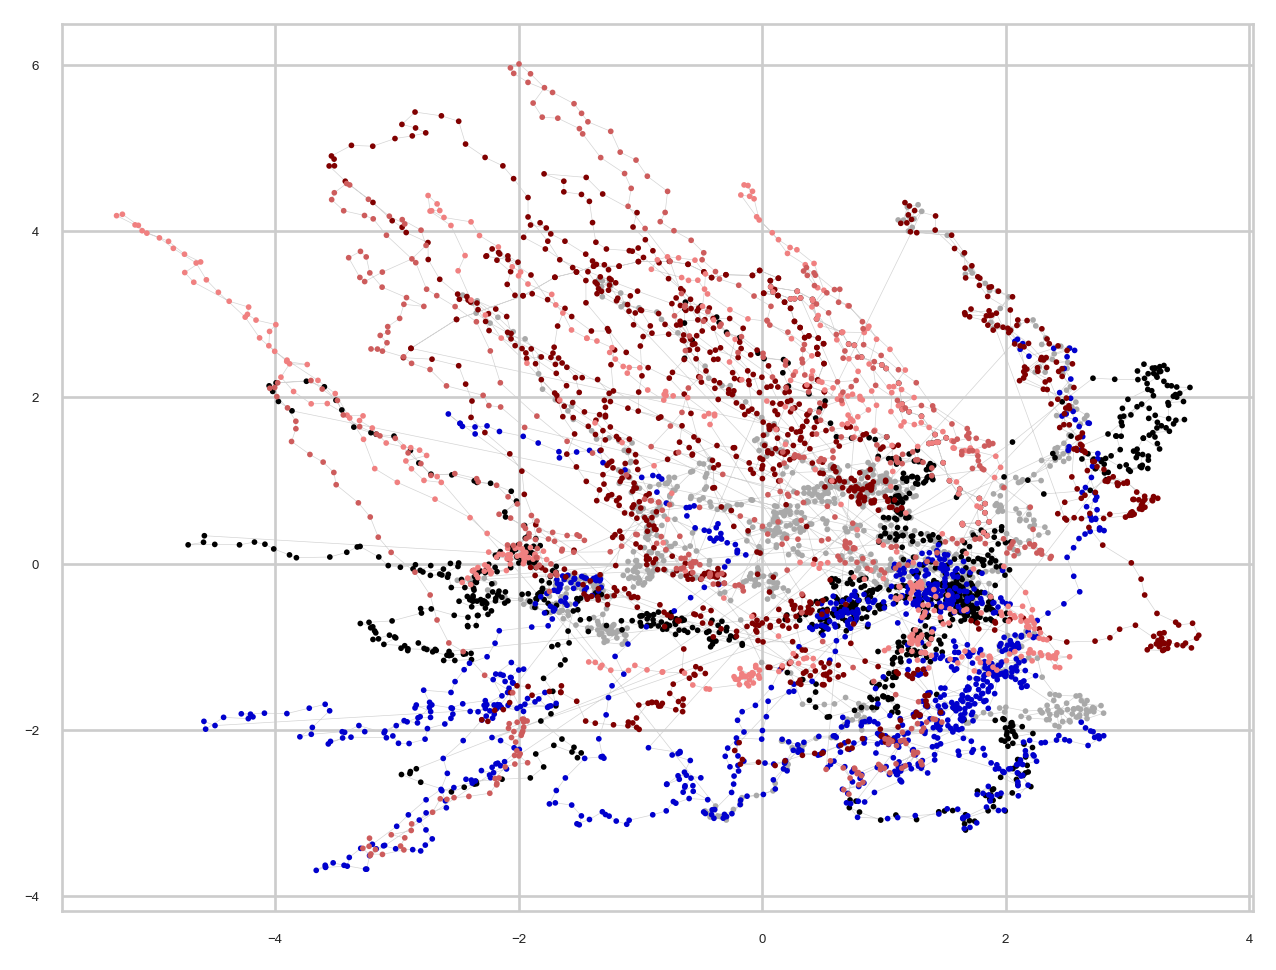

In [130]:
fig, ax = plt.subplots(1, 1, dpi = 240)
ax.plot(X_pca[stim_id_ofinterest, 1], X_pca[stim_id_ofinterest, 2], linewidth = 0.2, zorder = -1, color = 'lightgrey')
ax.scatter(X_pca[stim_id_ofinterest, 1], X_pca[stim_id_ofinterest,2], s = 0.5, c = np.array(stim_ids)[stim_id_ofinterest])